# Embeddings in Recommender systems

Learning about recommender systems and embeddings using keras and pytorch


Following the separate plans generated with AI. We will start with Keras (easier code) and then do pytorch.

AI use: The goal here is to use AI as a teaching tool, but I will write all the code myself to reinforce the concepts and execution.

In [7]:
# Load libraries
import pandas as pd
import numpy as np
import tensorflow as tf
import torch
from torch import nn
from torch.utils.data import DataLoader
import os
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

# Phase 1
## Load the data
Import the data, and save it to a folder for later reloading

In [2]:
# Get the data saved to files
ratings_url = "https://raw.githubusercontent.com/zygmuntz/goodbooks-10k/refs/heads/master/ratings.csv"
books_url = "https://raw.githubusercontent.com/zygmuntz/goodbooks-10k/refs/heads/master/books.csv"

local_dir = "data"
ratings_path = os.path.join(local_dir,"ratings.csv")
books_path = os.path.join(local_dir,"books.csv")

os.makedirs(local_dir,exist_ok=True)

if not os.path.exists(ratings_path) and not os.path.exists(books_path):
    ratings = pd.read_csv(ratings_url)
    ratings.to_csv(ratings_path,index=False)

    books = pd.read_csv(books_url)
    books.to_csv(books_path,index=False)
else:
    ratings = pd.read_csv(ratings_path)
    books = pd.read_csv(books_path)

## Merge and clean IDs

In [3]:
ratings['user_idx'] = ratings['user_id'].astype('category').cat.codes
ratings['book_idx'] = ratings['book_id'].astype('category').cat.codes

ratings.head()

,user_id,book_id,rating,user_idx,book_idx
0,1,258,5,0,257
1,2,4081,4,1,4080
2,2,260,5,1,259
3,2,9296,5,1,9295
4,2,2318,3,1,2317


In [4]:
# Create dictionaries to map between original ids and the new 0-indexed idx's
book_id_to_idx = dict(zip(ratings['book_id'],ratings['book_idx']))
idx_to_book_id = {v: k for k, v in book_id_to_idx.items()}

user_id_to_idx = dict(zip(ratings['user_id'],ratings['user_idx']))
idx_to_user_id = {v: k for k, v in user_id_to_idx.items()}

# Phase 2: Data pipeline

## Train/validation/test split

In [5]:
# 80% training, 10% validation, 10% testing
train_df, temp_df = train_test_split(ratings, test_size=0.2, random_state=2026)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=2026)

## Create datasets

In [6]:
# simple function to crease tf datasets from the dataframes
def create_tf_dataset(df, batch_size=2048, shuffle=True):
    # create slices (?)
    ds = tf.data.Dataset.from_tensor_slices((
        # a dictionary of the user and book indices as input, and the rating as output
        {'user_id': df['user_idx'].values, 'book_id': df['book_idx'].values},
         df['rating'].values))
    if shuffle:
        # shuffle the dataset (buffer size = length of the dataframe)
        ds = ds.shuffle(buffer_size=len(df))
    # batch the dataset, cache it, and prefetch it for performance
    ds = ds.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_tf_dataset(train_df)
val_ds = create_tf_dataset(val_df, shuffle=False)
test_ds = create_tf_dataset(test_df, shuffle=False)

# Phase 3: Define Model
*   **Input Layers:** Create two `tf.keras.layers.Input` layers, one for `user_input` and one for `book_input`.
*   **Embedding Layers:** 
    *   Create `tf.keras.layers.Embedding` layers for users and books. Apply `tf.keras.regularizers.l2(1e-5)` directly within the embedding layer definition to prevent overfitting.
    *   Create bias embedding layers (output dimension = 1) for users and books.
*   **Dot Product & Addition:** 
    *   Use `tf.keras.layers.Dot(axes=1)` to compute the interaction between the user and book embeddings.
    *   Use `tf.keras.layers.Add()` to add the dot product and the two bias terms together.
*   **Model Compilation:** 
    *   Define the model: `model = tf.keras.Model(inputs=[user_input, book_input], outputs=prediction)`.

In [7]:
embedding_dim = 32

# user input is just grabbing the user_id column 
user_input = tf.keras.Input(shape=(), dtype=tf.int32, name='user_id')
# embedding with a +1 for unknown users, output dimension = embedding_dim, and L2 regularization
user_embedding = tf.keras.layers.Embedding(
    input_dim=len(user_id_to_idx)+1,
    output_dim = embedding_dim,
    embeddings_regularizer = tf.keras.regularizers.l2(1e-5),
    name = 'user_embedding')(user_input) # calling the layer on the user_input to get the actual embeddings

# bias embedding with output dimension = 1 and L2 regularization
user_bias = tf.keras.layers.Embedding(
    input_dim = len(user_id_to_idx) + 1,
    output_dim = 1,
    embeddings_regularizer = tf.keras.regularizers.l2(1e-5),
    name = 'user_bias')(user_input)

# same here for books
book_input = tf.keras.Input(shape=(), dtype=tf.int32, name='book_id')
book_embedding = tf.keras.layers.Embedding(
    input_dim = len(book_id_to_idx) + 1,
    output_dim = embedding_dim,
    embeddings_regularizer = tf.keras.regularizers.l2(1e-5),
    name = 'book_embedding')(book_input)
book_bias = tf.keras.layers.Embedding(
    input_dim = len(book_id_to_idx) + 1,
    output_dim = 1,
    embeddings_regularizer = tf.keras.regularizers.l2(1e-5),
    name = 'book_bias')(book_input)

# target is the dot product of the user and book embeddings, plus the user and book bias terms
score = tf.keras.layers.Dot(axes=1)([user_embedding, book_embedding])
score = tf.keras.layers.Add()([score, user_bias, book_bias])

# construct model with inputs and outputs
model = tf.keras.Model(inputs=[user_input, book_input], outputs = score)

# how model should be trained
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    loss = tf.keras.losses.MeanSquaredError()
)

# Phase 4: Training
*   **Compilation:** `model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')`.
*   **Callbacks:**
    *   Use `tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)` to automatically handle overfitting.
*   **Execution:** Call `model.fit(train_dataset, validation_data=val_dataset, epochs=20, callbacks=[early_stopping])`. This single line replaces the entire custom loop required in PyTorch.

In [8]:
# fit the model. this may be slow...
model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 10,
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    ]
)

Epoch 1/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6.3846 - val_loss: 2.2318
Epoch 2/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 2.1640 - val_loss: 2.1248
Epoch 3/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 2.0842 - val_loss: 2.0532
Epoch 4/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 2.0177 - val_loss: 1.9962
Epoch 5/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 1.9659 - val_loss: 1.9535
Epoch 6/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 1.9266 - val_loss: 1.9212
Epoch 7/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 1.8964 - val_loss: 1.8966
Epoch 8/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 1.8730 - val_loss: 1.8774
Epoch 9/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 1.8545 - val_loss: 1.8626
Epoch 10/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 1.8398 - val_loss: 1.8509


In [9]:
# Evaluate on the test set
test_loss = model.evaluate(test_ds)
print(f"Test MSE Loss: {test_loss}")

292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.8494
Test MSE Loss: 1.8494219779968262


## Phase 5: Extraction, Visualization, and Analysis
*   **Extract Weights:** Access the weights directly from the layer: `book_embeddings = model.get_layer('book_embedding').get_weights()[0]`.
*   **Dimensionality Reduction:** Use Scikit-learn's `TSNE` or `UMAP` to map the arrays to 2D.
*   **Visualization:** Create an interactive scatter plot with Plotly.
*   **Vector Math:** Use Scikit-learn's `cosine_similarity` module to find the nearest neighbors for a target book embedding.

In [ ]:
trained_book_embeddings = model.get_layer('book_embedding').get_weights()[0]

book_embeddings_2d = TSNE(n_components=2, random_state=2026).fit_transform(trained_book_embeddings)

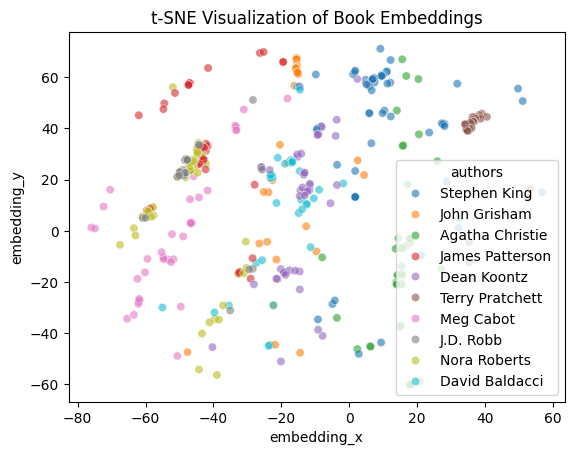

In [40]:
# plot the top 5 authors
top_authors = books['authors'].value_counts().head(10).index
books['top_author'] = books['authors'].isin(top_authors)

# Create a dataframe for visualization
books['embedding_x'] = book_embeddings_2d[:-1,0]
books['embedding_y'] = book_embeddings_2d[:-1,1]
# sns.scatterplot(data=books[~books['top_author']], x='embedding_x', y='embedding_y', 
#                 alpha = 0.6, color = 'gray', label = 'Other authors')
sns.scatterplot(data=books[books['top_author']], x='embedding_x', y='embedding_y', 
                alpha = 0.6, hue = 'authors')
plt.title("t-SNE Visualization of Book Embeddings")
plt.show()

In [36]:
books.head()

,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url,embedding_x,embedding_y
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...,-19.662241,80.865318
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...,-15.511432,82.751968
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...,-26.305069,77.950912
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...,42.058861,72.111092
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...,52.118652,70.089745


Now we can repeat the same analysis with torch. Phase 1 will be exactly the same, so we can pick it up with phase 2, loading the data into pytorch format

In [33]:
# create torch datasets from the dataframes
class BookRatingsDataset(torch.utils.data.Dataset):
    def __init__(self, df):
        self.user_ids = torch.tensor(df['user_idx'].values, dtype=torch.long)
        self.book_ids = torch.tensor(df['book_idx'].values, dtype=torch.long)
        self.ratings = torch.tensor(df['rating'].values, dtype=torch.float32)
    
    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.user_ids[idx], self.book_ids[idx],self.ratings[idx]


train_dl = DataLoader(
    BookRatingsDataset(train_df),
    batch_size=2048,
    shuffle=True
)
val_dl = DataLoader(
    BookRatingsDataset(val_df),
    batch_size=2048,
    shuffle=False
)
test_dl = DataLoader(
    BookRatingsDataset(test_df),
    batch_size=2048,
    shuffle=False
)

## Phase 3: Defining the Matrix Factorization Model (PyTorch)
*   **The Architecture:** Subclass `nn.Module`. Include `nn.Embedding` for users, books, user biases, and book biases.
*   **The Forward Pass:** Compute the dot product of user and book embeddings, then add both biases.
*   **Initialization:** 
    *   *Critical Review Improvement:* Neural networks are sensitive to initialization. Explicitly initialize the embedding weights using a normal distribution with a small standard deviation (e.g., `std=0.01`) and initialize biases to zero.


In [34]:
class BookModel(nn.Module):
    def __init__(self, num_users, num_books, embedding_dim=32):
        super().__init__()
        self.user_embedding = nn.Embedding(num_users + 1, embedding_dim)
        self.user_bias = nn.Embedding(num_users + 1, 1)
        self.book_embedding = nn.Embedding(num_books + 1, embedding_dim)
        self.book_bias = nn.Embedding(num_books + 1, 1)

        nn.init.normal_(self.user_embedding.weight, std=0.01)
        nn.init.normal_(self.book_embedding.weight, std=0.01)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.book_bias.weight)

    def forward(self, user_id, book_id):
        user_emb = self.user_embedding(user_id)
        user_b = self.user_bias(user_id).squeeze()
        book_emb = self.book_embedding(book_id)
        book_b = self.book_bias(book_id).squeeze()
        dot_product = (user_emb * book_emb).sum(dim=1)
        score = dot_product + user_b + book_b
        return score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = BookModel(num_users=len(user_id_to_idx), num_books=len(book_id_to_idx), embedding_dim=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.MSELoss()


In [ ]:
# Training loop consists of several steps
# Looping over epochs, set to training mode, loop over batches. this is the setup
best_val_loss = float('inf')
patience = 3
epochs_no_improve = 0
best_model_state = None

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for user_id, book_id, rating in train_dl:
        user_id = user_id.to(device)
        book_id = book_id.to(device)
        rating = rating.float().to(device)

        optimizer.zero_grad()
# Forward pass
        outputs = model(user_id, book_id)
        loss = criterion(outputs, rating.float())

# Calulate loss
        loss.backward()
# backward pass and update weights
        optimizer.step()
        running_loss += loss.item() * rating.size(0)

    train_loss = running_loss / len(train_dl.dataset)
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}")

    # Validation loop
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for user_id, book_id, rating in val_dl:
            user_id = user_id.to(device)
            book_id = book_id.to(device)
            rating = rating.float().to(device)

            outputs = model(user_id, book_id)
            loss = criterion(outputs, rating.float())
            val_running_loss += loss.item() * rating.size(0)

    val_loss = val_running_loss / len(val_dl.dataset)
    print(f"Epoch {epoch+1}/{num_epochs}, Validation Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_state = model.state_dict()
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping triggered. Restoring best model weights.")
            model.load_state_dict(best_model_state)
            break


Epoch 1/10, Train Loss: 4.5288
Epoch 1/10, Validation Loss: 0.8714
Epoch 2/10, Train Loss: 0.8083
Epoch 2/10, Validation Loss: 0.7951
Epoch 3/10, Train Loss: 0.7876
Epoch 3/10, Validation Loss: 0.7900
Epoch 4/10, Train Loss: 0.7818
Epoch 4/10, Validation Loss: 0.7836
Epoch 5/10, Train Loss: 0.7722
Epoch 5/10, Validation Loss: 0.7743
Epoch 6/10, Train Loss: 0.7596
Epoch 6/10, Validation Loss: 0.7653
Epoch 7/10, Train Loss: 0.7469
Epoch 7/10, Validation Loss: 0.7559
Epoch 8/10, Train Loss: 0.7347
Epoch 8/10, Validation Loss: 0.7477
Epoch 9/10, Train Loss: 0.7226
Epoch 9/10, Validation Loss: 0.7390
Epoch 10/10, Train Loss: 0.7107
Epoch 10/10, Validation Loss: 0.7324
Test MSE Loss: 0.7297


In [36]:

# Evaluate on the test set
model.eval()
test_running_loss = 0.0
with torch.no_grad():
    for user_id, book_id, rating in test_dl:
        user_id = user_id.to(device)
        book_id = book_id.to(device)
        rating = rating.float().to(device)

        outputs = model(user_id, book_id)
        loss = criterion(outputs, rating.float())
        test_running_loss += loss.item() * rating.size(0)
test_loss = test_running_loss / len(test_dl.dataset)
print(f"Test MSE Loss: {test_loss:.4f}")

Test MSE Loss: 0.7297


In [42]:
book_embeddings_torch = model.book_embedding.weight.detach().cpu().numpy()

book_embeddings_2d_torch = TSNE(n_components=2, random_state=2026).fit_transform(book_embeddings_torch)

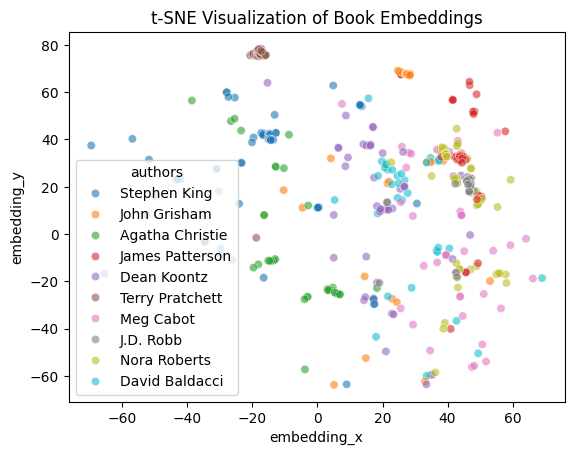

In [43]:
# plot the top 5 authors
top_authors = books['authors'].value_counts().head(10).index
books['top_author'] = books['authors'].isin(top_authors)

# Create a dataframe for visualization
books['embedding_x'] = book_embeddings_2d_torch[:-1,0]
books['embedding_y'] = book_embeddings_2d_torch[:-1,1]
# sns.scatterplot(data=books[~books['top_author']], x='embedding_x', y='embedding_y', 
#                 alpha = 0.6, color = 'gray', label = 'Other authors')
sns.scatterplot(data=books[books['top_author']], x='embedding_x', y='embedding_y', 
                alpha = 0.6, hue = 'authors')
plt.title("t-SNE Visualization of Book Embeddings")
plt.show()